# PCA on i24 Vehicle Trajectory Features
End-to-end Principal Components Analysis on the i24 moving vehicle dataset — 17 pre-chunked CSV files covering the same feature schema as `pca_vehicles.ipynb`.

## 1. Import Required Libraries

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load and Explore the i24 Data

In [2]:

# ── CONFIG ─────────────────────────────────────────────────────────────────────
I24_DIR = 'i24'   # folder containing i24_chunk_01.csv … i24_chunk_17.csv

# ── Load regular chunks ────────────────────────────────────────────────────────
chunk_files = sorted(glob.glob(f'{I24_DIR}/i24_chunk_[0-9]*.csv'))
# Exclude outlier files from regular loading
chunk_files = [f for f in chunk_files if '_outliers' not in f]
print(f'Found {len(chunk_files)} regular chunk files')

chunks = []
for f in chunk_files:
    chunk_num = int(f.split('_chunk_')[1].split('.')[0])
    tmp = pd.read_csv(f)
    tmp['chunk'] = chunk_num
    tmp['is_synthetic'] = False
    chunks.append(tmp)

# ── Load synthetic outlier files ───────────────────────────────────────────────
outlier_files = sorted(glob.glob(f'{I24_DIR}/i24_chunk_*_outliers.csv'))
print(f'Found {len(outlier_files)} synthetic outlier file(s)')

for f in outlier_files:
    chunk_num = int(f.split('_chunk_')[1].split('_')[0])
    tmp = pd.read_csv(f)
    tmp['chunk'] = chunk_num
    tmp['is_synthetic'] = True
    chunks.append(tmp)

df = pd.concat(chunks, ignore_index=True)
n_synth = df['is_synthetic'].sum()
print(f'Raw shape: {df.shape}  ({n_synth} synthetic rows)')
print(f'Columns  : {df.columns.tolist()}')


Found 17 regular chunk files
Found 1 synthetic outlier file(s)
Raw shape: (830402, 69)  (36 synthetic rows)
Columns  : ['vel_min', 'vel_max', 'vel_mean', 'vel_std', 'acc_min', 'acc_max', 'acc_mean', 'acc_std', 'jerk_min', 'jerk_max', 'jerk_mean', 'jerk_std', 'acc_dir_min', 'acc_dir_max', 'acc_dir_mean', 'acc_dir_std', 'jerk_dir_min', 'jerk_dir_max', 'jerk_dir_mean', 'jerk_dir_std', 'curv_min', 'curv_max', 'curv_mean', 'curv_std', 'delta_x', 'delta_y', 'path', 'delta_t', 'frac_stop', 'frac_accel', 'frac_break', 'x_0', 'y_0', 'x_1', 'y_1', 'x_2', 'y_2', 'x_3', 'y_3', 'x_4', 'y_4', 'x_5', 'y_5', 'x_6', 'y_6', 'x_7', 'y_7', 'x_8', 'y_8', 'x_9', 'y_9', 'object_id', 'intersection_id', 'classification', 'sub_classification', 'obj_length', 'obj_width', 'obj_height', 'direction', 'compute_node_id', 'starting_x', 'first_timestamp', 'configuration_id', 'ending_x', 'last_timestamp', 'x_score', 'y_score', 'chunk', 'is_synthetic']
Found 1 synthetic outlier file(s)
Raw shape: (830402, 69)  (36 synthe

In [3]:
# ── Drop duplicated object_ids (same vehicle seen multiple times) ──────────────
dup_mask = df['object_id'].duplicated(keep=False)
n_removed = dup_mask.sum()
df = df[~dup_mask].reset_index(drop=True)
print(f'Removed {n_removed:,} rows with duplicated object_ids  '
      f'({df["object_id"].nunique():,} unique trajectories remain)')

print('\nClass distribution:')
print(df['classification'].value_counts())
print('\nSub-class distribution:')
print(df['sub_classification'].value_counts())
df.head(3)

Removed 0 rows with duplicated object_ids  (830,402 unique trajectories remain)

Class distribution:
classification
1    302136
0    285066
3    135793
4     67289
2     28277
5     11841
Name: count, dtype: int64

Sub-class distribution:
sub_classification
-1    830402
Name: count, dtype: int64


,vel_min,vel_max,vel_mean,vel_std,acc_min,acc_max,acc_mean,acc_std,jerk_min,jerk_max,...,compute_node_id,starting_x,first_timestamp,configuration_id,ending_x,last_timestamp,x_score,y_score,chunk,is_synthetic
0,33.955188,44.645139,37.072131,3.258173,22.671874,45.460152,43.595278,6.161289,0.052687,568.196098,...,videonode7,324427.104744,1.669032e+09,-1,324460.175121,1.669032e+09,2.117509,0.574939,1,False
1,23.734155,27.877611,24.856096,1.186582,6.123951,12.898983,12.496354,1.375736,0.004675,159.525338,...,videonode5,320369.844015,1.669032e+09,-1,320402.039945,1.669032e+09,3.145649,0.699438,1,False
2,107.694220,109.351442,108.682826,0.514732,1.413725,3.029943,2.872192,0.292431,0.000340,37.806856,...,videonode4,318523.288494,1.669032e+09,-1,318749.230282,1.669032e+09,3.693897,0.374060,1,False


## 3. Visualise Feature Distributions

830,402 trajectories after range filter  (36 synthetic)


/var/folders/d9/vp7jkvm979jc2_fkp1g0jxzm0000gn/T/ipykernel_53739/379332938.py:60: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/dmitriikhitrin/anaconda3/envs/dry-dock/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dmitriikhitrin/anaconda3/envs/dry-dock/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


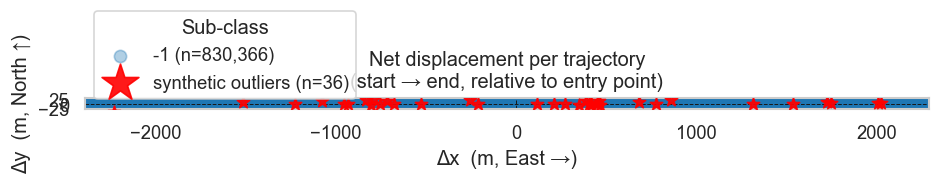

In [4]:

# --- Net displacement scatter: delta_x vs delta_y ---
disp_df = df[['delta_x', 'delta_y', 'sub_classification', 'is_synthetic']].dropna(subset=['delta_x', 'delta_y'])

# ── CONFIG ────────────────────────────────────────────────────────────────────
CLIP = 1.0   # percentile clip to suppress extreme outliers (ignored if ranges are set)

# Paired 2D cells: row is kept if it falls inside ANY (DELTA_X_RANGE[i], DELTA_Y_RANGE[i]) box.
# Both lists must have the same length, or set both to None for no filter.
DELTA_X_RANGE = None
DELTA_Y_RANGE = None

# ── Helper: mask rows matching ANY paired (x_range[i], y_range[i]) box ───────
def _range_mask(dx, dy, x_ranges, y_ranges):
    """Return boolean Series: True if (dx, dy) falls in at least one paired cell."""
    if x_ranges is None and y_ranges is None:
        return pd.Series(True, index=dx.index)
    assert x_ranges is not None and y_ranges is not None, \
        "DELTA_X_RANGE and DELTA_Y_RANGE must both be set or both be None"
    assert len(x_ranges) == len(y_ranges), \
        f"DELTA_X_RANGE and DELTA_Y_RANGE must have the same length (got {len(x_ranges)} vs {len(y_ranges)})"
    mask = pd.Series(False, index=dx.index)
    for (xlo, xhi), (ylo, yhi) in zip(x_ranges, y_ranges):
        mask |= dx.between(xlo, xhi) & dy.between(ylo, yhi)
    return mask

# ── Apply range filter ────────────────────────────────────────────────────────
disp_df = disp_df[_range_mask(disp_df['delta_x'], disp_df['delta_y'], DELTA_X_RANGE, DELTA_Y_RANGE)]
print(f'{len(disp_df):,} trajectories after range filter  '
      f'({disp_df["is_synthetic"].sum()} synthetic)')

# ── Axis limits: union of all ranges if provided, else percentile clip ────────
real_df = disp_df[~disp_df['is_synthetic']]
if DELTA_X_RANGE is not None:
    xlim = (min(lo for lo, _ in DELTA_X_RANGE), max(hi for _, hi in DELTA_X_RANGE))
    ylim = (min(lo for lo, _ in DELTA_Y_RANGE), max(hi for _, hi in DELTA_Y_RANGE))
else:
    xlim = (np.percentile(real_df['delta_x'], CLIP), np.percentile(real_df['delta_x'], 100 - CLIP))
    ylim = (np.percentile(real_df['delta_y'], CLIP), np.percentile(real_df['delta_y'], 100 - CLIP))

palette = sns.color_palette('tab10', n_colors=disp_df['sub_classification'].nunique())
fig, ax = plt.subplots(figsize=(8, 8))

for color, (sc, grp) in zip(palette, disp_df[~disp_df['is_synthetic']].groupby('sub_classification')):
    ax.scatter(grp['delta_x'], grp['delta_y'],
               s=6, alpha=0.35, color=color, label=f'{sc} (n={len(grp):,})')

# ── Overlay synthetic points in red ──────────────────────────────────────────
synth = disp_df[disp_df['is_synthetic']]
if not synth.empty:
    ax.scatter(synth['delta_x'], synth['delta_y'],
               s=60, alpha=0.9, color='red', marker='*', zorder=5,
               label=f'synthetic outliers (n={len(synth)})')

ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
ax.axvline(0, color='k', linewidth=0.6, linestyle='--')
ax.set(xlabel='Δx  (m, East →)', ylabel='Δy  (m, North ↑)',
       title='Net displacement per trajectory\n(start → end, relative to entry point)',
       aspect='equal', xlim=xlim, ylim=ylim)
ax.legend(markerscale=3, title='Sub-class')
plt.tight_layout()
plt.show()


In [5]:
# Summary statistics for numeric features
FEATURE_COLS = [
    c for c in df.columns
    if df[c].dtype == float and c not in ('object_id', 'intersection_id')
]
print(f'{len(FEATURE_COLS)} numeric feature columns')
df[FEATURE_COLS].describe().T[['mean','std','min','max']].style.background_gradient(axis=0)

60 numeric feature columns


,mean,std,min,max
vel_min,51.820382,39.595037,0.000001,785.688260
vel_max,65.769659,39.570455,0.017655,785.950487
vel_mean,58.802129,39.610849,0.001739,785.810566
vel_std,4.215355,3.435917,0.000187,50.019608
acc_min,0.450690,1.207309,0.000000,232.934293
acc_max,4.485925,10.161326,0.000396,2831.839021
acc_mean,2.362029,2.302222,0.000194,399.324732
acc_std,1.126138,1.880338,0.000113,834.926305
jerk_min,0.030632,0.102127,0.000000,4.113345
jerk_max,37.106888,248.665507,0.009113,70794.378636


## 4. Preprocess the Data

Each row is one complete vehicle trajectory.

**Feature groups:**
| Group | Features | `MAGNITUDE_ONLY` |
|---|---|---|
| Speed | `vel_min/max/mean/std` | ✅ keep |
| Acceleration (magnitude) | `acc_min/max/mean/std` | ✅ keep |
| Jerk (magnitude) | `jerk_min/max/mean/std` | ✅ keep |
| Directional acc / jerk | `acc_dir_*/jerk_dir_*` | ✅ keep |
| Curvature | `curv_min/max/mean/std` | ✅ keep |
| Behaviour fractions | `frac_stop / frac_accel / frac_break` | ✅ keep |
| Path length & duration | `path`, `delta_t` | ✅ keep |
| Object size | `obj_length/width/height` | ✅ keep |
| Net displacement | `delta_x`, `delta_y` | ❌ drop |
| Path waypoints | `x_0..y_N` | ❌ drop |

**Configuration knobs:**
- `FILTER_CLASS` — object class to keep (`'VEHICLE'`, or `None` for all).
- `MIN_SPEED` — minimum trajectory mean speed (m/s); removes parked / barely-moving objects.
- `MAGNITUDE_ONLY` — drop spatial/directional features (`delta_x/y`, `x_*/y_*`).

In [6]:
# ── CONFIG ─────────────────────────────────────────────────────────────────────
FILTER_CLASS    = None    # None = keep all classes (i24 rows are already vehicles)
MIN_SPEED       = 5.0     # m/s — drop trajectories with vel_mean below this
MAGNITUDE_ONLY  = True    # True = drop spatial/directional cols (delta_x/y, x_*/y_*)

# ── Class filter ───────────────────────────────────────────────────────────────
if FILTER_CLASS:
    data = df[df['classification'] == FILTER_CLASS].copy()
else:
    data = df.copy()

# ── Spatial range filter (from displacement scatter) ──────────────────────────
before_spatial = len(data)
data = data[_range_mask(data['delta_x'], data['delta_y'], DELTA_X_RANGE, DELTA_Y_RANGE)]
if DELTA_X_RANGE is not None:
    print(f'Spatial range filter : {len(data):,}  (dropped {before_spatial - len(data):,})')
    for i, (xr, yr) in enumerate(zip(DELTA_X_RANGE, DELTA_Y_RANGE)):
        print(f'  Cell {i}: x={xr}  y={yr}')

# ── NaN / inf cleanup ──────────────────────────────────────────────────────────
data[FEATURE_COLS] = data[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
before_nan = len(data)
data = data.dropna(subset=FEATURE_COLS)
print(f'After class filter & NaN drop : {len(data):,}  (dropped {before_nan - len(data):,})')

# ── Speed filter ───────────────────────────────────────────────────────────────
before_speed = len(data)
data = data[data['vel_mean'] >= MIN_SPEED].copy()
print(f'\nSpeed filter  (vel_mean ≥ {MIN_SPEED} m/s = {MIN_SPEED*3.6:.1f} km/h)')
print(f'  Pass : {len(data):,}  ({len(data)/before_speed*100:.1f}%)')
print(f'  Drop : {before_speed - len(data):,}  ({(before_speed-len(data))/before_speed*100:.1f}%)')
print(f'\nSub-class breakdown:')
print(data['sub_classification'].value_counts().to_string())

# ── Feature selection ──────────────────────────────────────────────────────────
DIRECTIONAL_EXACT    = {'delta_x', 'delta_y'}
DIRECTIONAL_PREFIXES = ('x_', 'y_')

if MAGNITUDE_ONLY:
    active_cols = [
        c for c in FEATURE_COLS
        if c not in DIRECTIONAL_EXACT
        and not any(c.startswith(p) for p in DIRECTIONAL_PREFIXES)
    ]
    print(f'\nMAGNITUDE_ONLY=True — keeping {len(active_cols)}/{len(FEATURE_COLS)} features (dropped spatial/directional)')
else:
    active_cols = FEATURE_COLS
    print(f'\nMAGNITUDE_ONLY=False — using all {len(active_cols)} features')

# ── Scale ──────────────────────────────────────────────────────────────────────
X = data[active_cols].values
labels = data['sub_classification'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Final scaled shape: {X_scaled.shape}')

After class filter & NaN drop : 828,169  (dropped 2,233)

Speed filter  (vel_mean ≥ 5.0 m/s = 18.0 km/h)
  Pass : 786,566  (95.0%)
  Drop : 41,603  (5.0%)

Sub-class breakdown:
sub_classification
-1    786566

MAGNITUDE_ONLY=True — keeping 36/60 features (dropped spatial/directional)
Final scaled shape: (786566, 36)

Speed filter  (vel_mean ≥ 5.0 m/s = 18.0 km/h)
  Pass : 786,566  (95.0%)
  Drop : 41,603  (5.0%)

Sub-class breakdown:
sub_classification
-1    786566

MAGNITUDE_ONLY=True — keeping 36/60 features (dropped spatial/directional)
Final scaled shape: (786566, 36)


## 5. Apply PCA

In [7]:
# Fit full PCA to inspect variance spectrum
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cumvar >= 0.90)) + 1
n_95 = int(np.argmax(cumvar >= 0.95)) + 1
print(f'Components to explain 90% variance: {n_90}')
print(f'Components to explain 95% variance: {n_95}')

# Refit with 95% threshold for downstream use
N_COMPONENTS = n_95
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA output shape: {X_pca.shape}')

Components to explain 90% variance: 12
Components to explain 95% variance: 14
PCA output shape: (786566, 14)


## 6. Visualise PCA Results

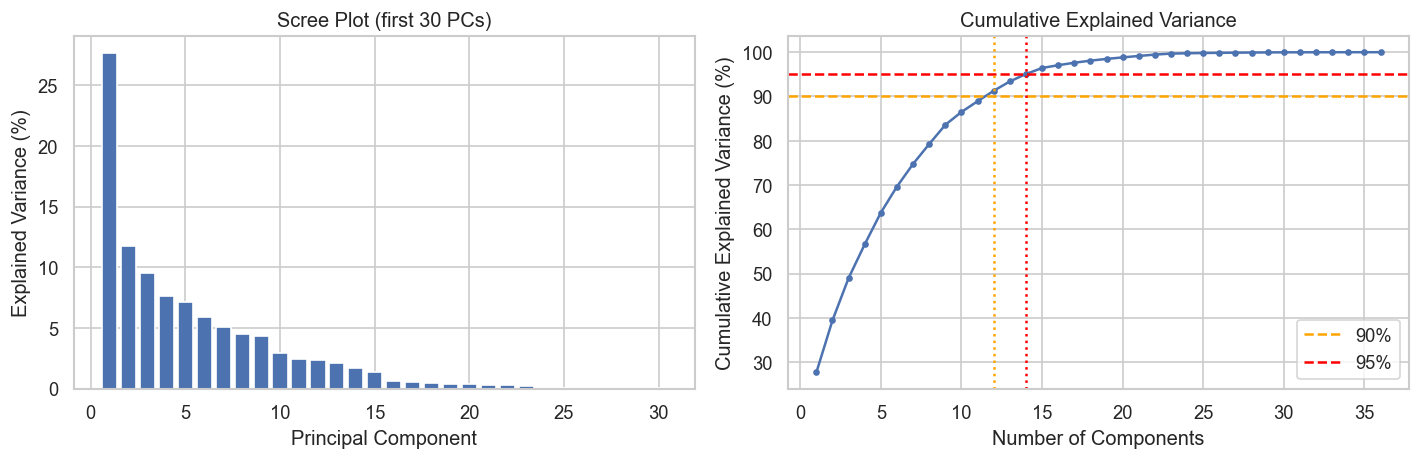

In [8]:
# --- 6a. Scree plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_show = min(30, len(pca_full.explained_variance_ratio_))
axes[0].bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100)
axes[0].set(xlabel='Principal Component', ylabel='Explained Variance (%)',
            title='Scree Plot (first 30 PCs)')

axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o', markersize=3)
axes[1].axhline(90, color='orange', linestyle='--', label='90%')
axes[1].axhline(95, color='red',    linestyle='--', label='95%')
axes[1].axvline(n_90, color='orange', linestyle=':')
axes[1].axvline(n_95, color='red',    linestyle=':')
axes[1].set(xlabel='Number of Components', ylabel='Cumulative Explained Variance (%)',
            title='Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

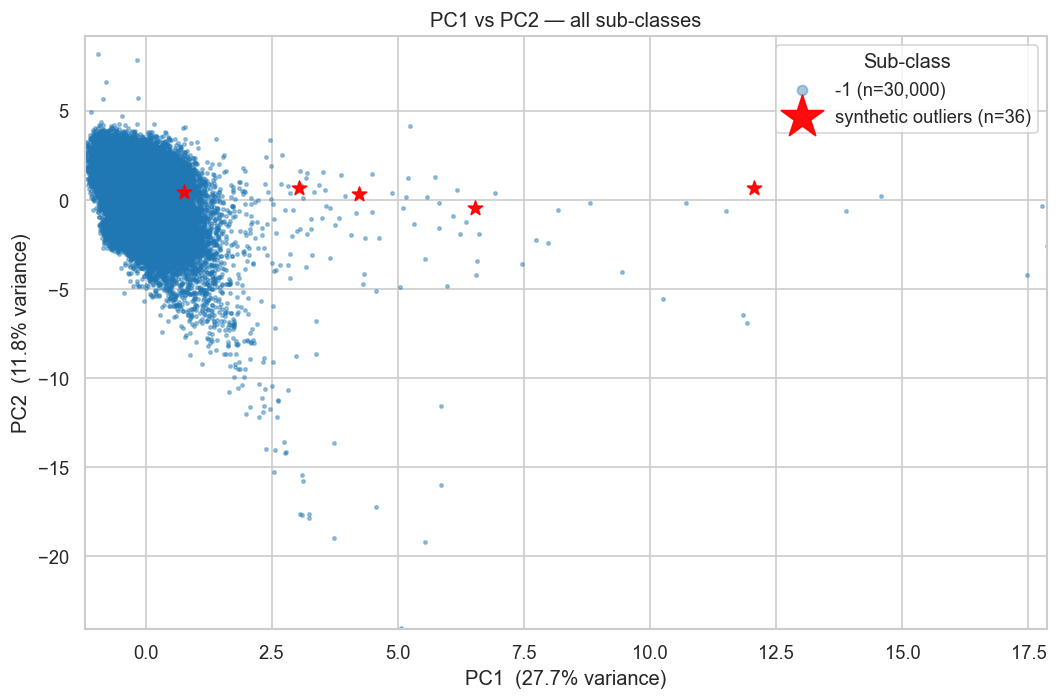

In [10]:

# --- 6b. Plot any pair of principal components ---
# ── CONFIG ────────────────────────────────────────────────────────────────────
PC_X = 1
PC_Y = 2

# Use None or an empty list to show ALL sub-classes
SHOW_SUBCLASSES = None   # e.g. ['car'], ['car', 'truck'], or None

MAX_POINTS = 30_000
CLIP_PCT   = 0.01         # clip axes at this percentile on each side

# ── validation ────────────────────────────────────────────────────────────────
assert 1 <= PC_X <= pca.n_components_, f"PC_X must be between 1 and {pca.n_components_}"
assert 1 <= PC_Y <= pca.n_components_, f"PC_Y must be between 1 and {pca.n_components_}"
assert PC_X != PC_Y, "PC_X and PC_Y must be different"

# ── build full plot_df including synthetic flag ────────────────────────────────
full_plot_df = pd.DataFrame({
    f'PC{PC_X}':      X_pca[:, PC_X - 1],
    f'PC{PC_Y}':      X_pca[:, PC_Y - 1],
    'sub_class':      labels,
    'is_synthetic':   data['is_synthetic'].values,
})

# ── subsample only the real points ────────────────────────────────────────────
real_mask = ~full_plot_df['is_synthetic']
rng  = np.random.default_rng(0)
real_idx = np.where(real_mask)[0]
sampled  = rng.choice(real_idx, size=min(MAX_POINTS, len(real_idx)), replace=False)
synth_idx = np.where(~real_mask)[0]
idx = np.concatenate([sampled, synth_idx])

plot_df = full_plot_df.iloc[idx].reset_index(drop=True)

# ── filter sub-classes ────────────────────────────────────────────────────────
if SHOW_SUBCLASSES:
    missing = [s for s in SHOW_SUBCLASSES if s not in plot_df['sub_class'].unique()]
    if missing:
        print(f"⚠️  Sub-classes not found in sample: {missing}")
        print(f"   Available: {sorted(plot_df['sub_class'].unique().tolist())}")
    real_part  = plot_df[~plot_df['is_synthetic'] & plot_df['sub_class'].isin(SHOW_SUBCLASSES)]
    synth_part = plot_df[plot_df['is_synthetic']]
    plot_df = pd.concat([real_part, synth_part])

if plot_df[~plot_df['is_synthetic']].empty:
    raise ValueError("No real data left after sub-class filter — check SHOW_SUBCLASSES.")

# ── percentile-based axis limits (real points only) ───────────────────────────
real_plot = plot_df[~plot_df['is_synthetic']]
xlim = (np.percentile(real_plot[f'PC{PC_X}'], CLIP_PCT), np.percentile(real_plot[f'PC{PC_X}'], 100 - CLIP_PCT))
ylim = (np.percentile(real_plot[f'PC{PC_Y}'], CLIP_PCT), np.percentile(real_plot[f'PC{PC_Y}'], 100 - CLIP_PCT))

# ── plot real points by sub-class ─────────────────────────────────────────────
palette = sns.color_palette('tab10', n_colors=real_plot['sub_class'].nunique())
fig, ax = plt.subplots(figsize=(9, 6))

for color, (sc, grp) in zip(palette, real_plot.groupby('sub_class')):
    ax.scatter(grp[f'PC{PC_X}'], grp[f'PC{PC_Y}'], s=4, alpha=0.4, color=color, label=f'{sc} (n={len(grp):,})')

# ── Overlay synthetic points in red ──────────────────────────────────────────
synth_plot = plot_df[plot_df['is_synthetic']]
if not synth_plot.empty:
    ax.scatter(synth_plot[f'PC{PC_X}'], synth_plot[f'PC{PC_Y}'],
               s=80, alpha=0.95, color='red', marker='*', zorder=5,
               label=f'synthetic outliers (n={len(synth_plot)})')

var_x = pca.explained_variance_ratio_[PC_X - 1] * 100
var_y = pca.explained_variance_ratio_[PC_Y - 1] * 100
ax.set(
    xlabel=f'PC{PC_X}  ({var_x:.1f}% variance)',
    ylabel=f'PC{PC_Y}  ({var_y:.1f}% variance)',
    title=f'PC{PC_X} vs PC{PC_Y} — {", ".join(SHOW_SUBCLASSES) if SHOW_SUBCLASSES else "all sub-classes"}',
    xlim=xlim, ylim=ylim,
)
ax.legend(markerscale=3, title='Sub-class')
plt.tight_layout()
plt.show()


## 7. Interpret Principal Components
A **loadings heatmap** shows which original features drive each PC.

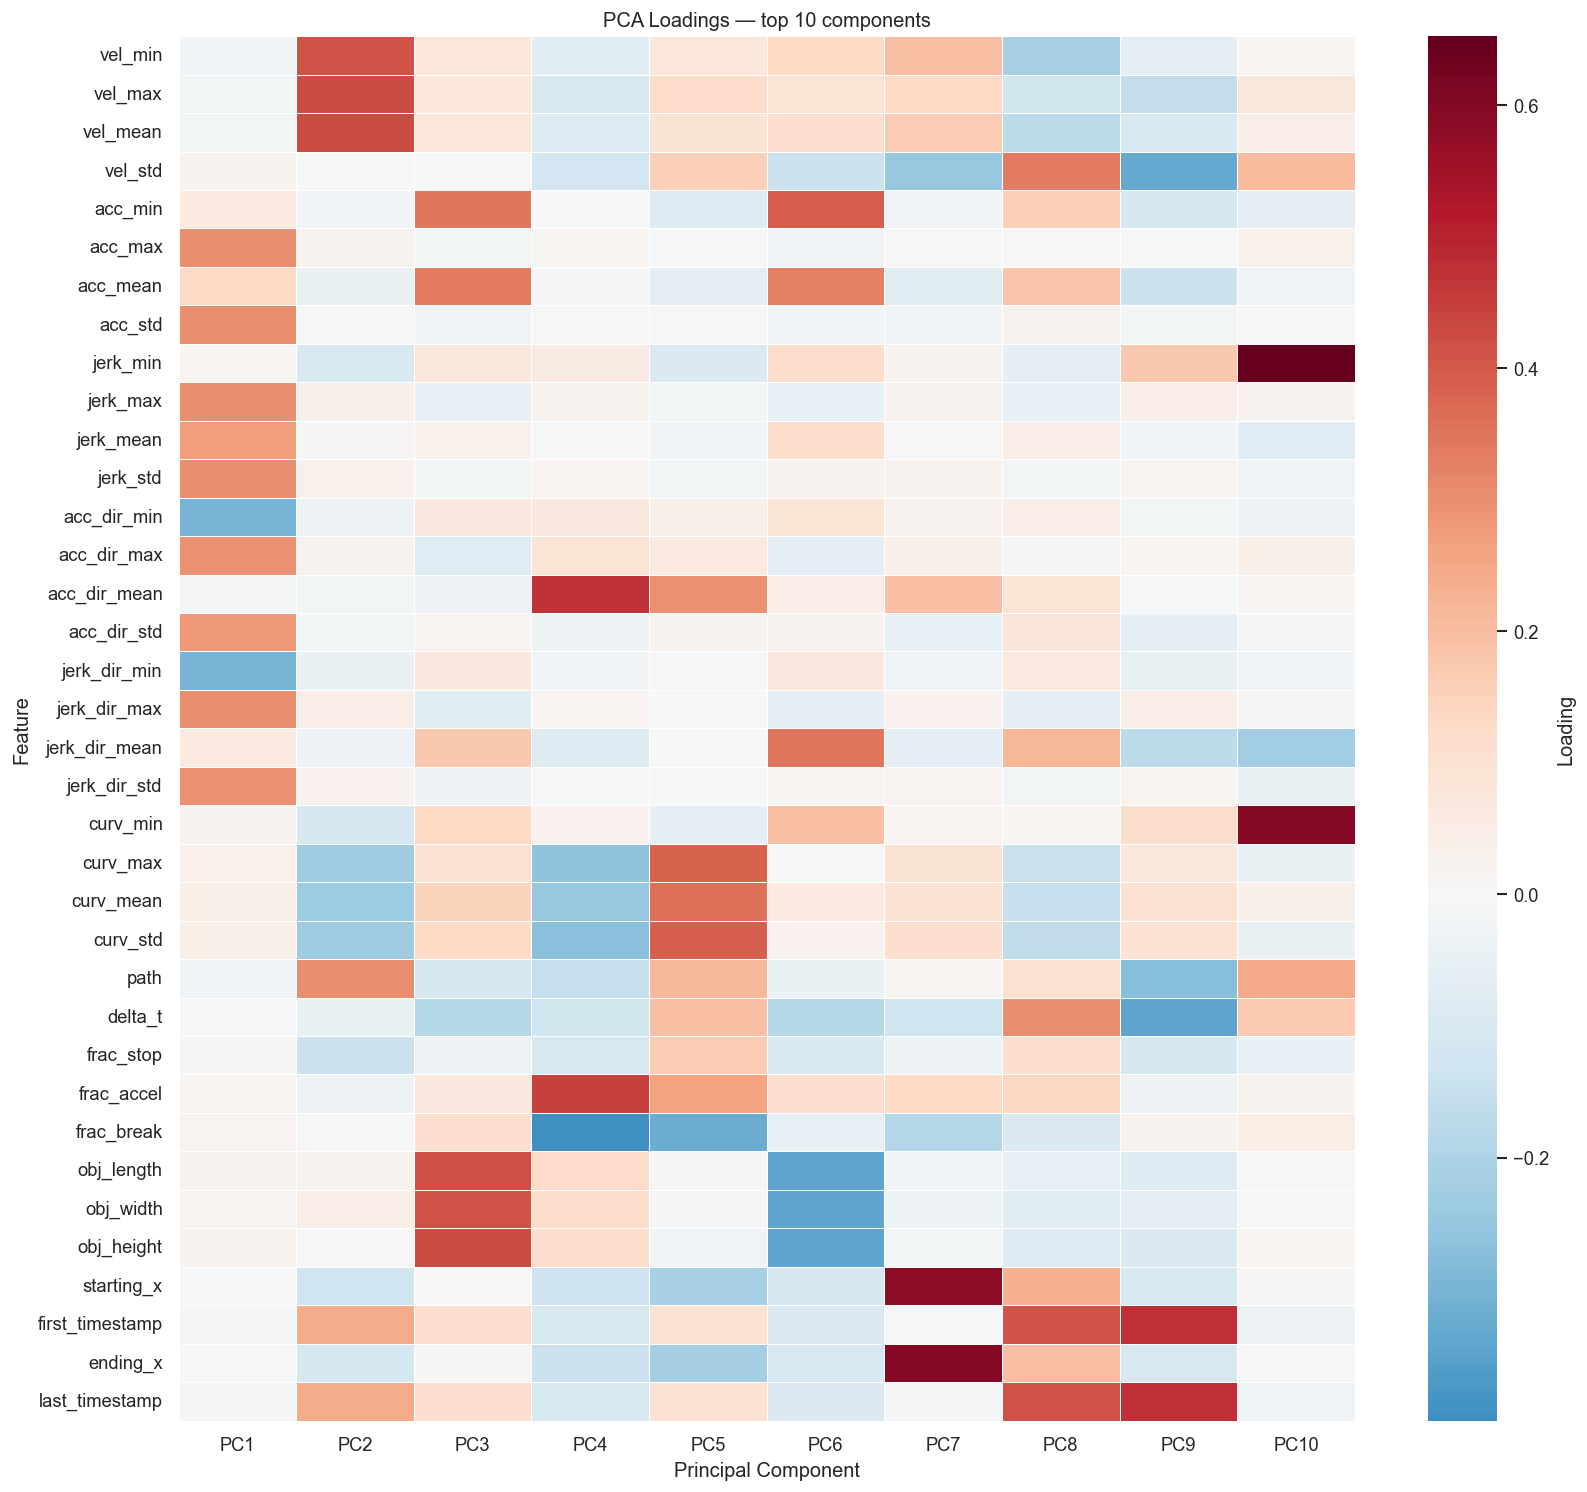

In [11]:
# --- 7a. Loadings heatmap for top 10 PCs ---
n_pc_show = min(10, pca.n_components_)
loadings = pd.DataFrame(
    pca.components_[:n_pc_show].T,
    index=active_cols,
    columns=[f'PC{i+1}' for i in range(n_pc_show)]
)

fig, ax = plt.subplots(figsize=(14, max(6, len(active_cols) * 0.35)))
sns.heatmap(loadings, cmap='RdBu_r', center=0, linewidths=0.3,
            cbar_kws={'label': 'Loading'}, ax=ax)
ax.set(title=f'PCA Loadings — top {n_pc_show} components', xlabel='Principal Component', ylabel='Feature')
plt.tight_layout()
plt.show()

In [12]:
# --- 7b. Top contributing features per PC ---
N_TOP = min(8, len(active_cols))
for pc_idx in range(min(5, pca.n_components_)):
    top = loadings[f'PC{pc_idx+1}'].abs().nlargest(N_TOP)
    var = pca.explained_variance_ratio_[pc_idx] * 100
    print(f'\nPC{pc_idx+1}  ({var:.1f}% variance explained) — top {N_TOP} features:')
    for feat, loading in zip(top.index, loadings[f'PC{pc_idx+1}'][top.index]):
        bar = '█' * int(abs(loading) * 30)
        sign = '+' if loading > 0 else '-'
        print(f'  {sign}{bar:<30}  {feat}  ({loading:+.3f})')


PC1  (27.7% variance explained) — top 8 features:
  +█████████                       acc_std  (+0.305)
  +█████████                       acc_max  (+0.305)
  +█████████                       jerk_std  (+0.304)
  +█████████                       jerk_max  (+0.301)
  -████████                        jerk_dir_min  (-0.299)
  +████████                        jerk_dir_max  (+0.299)
  -████████                        acc_dir_min  (-0.298)
  +████████                        jerk_dir_std  (+0.297)

PC2  (11.8% variance explained) — top 8 features:
  +████████████                    vel_mean  (+0.426)
  +████████████                    vel_max  (+0.423)
  +████████████                    vel_min  (+0.417)
  +█████████                       path  (+0.302)
  +███████                         first_timestamp  (+0.245)
  +███████                         last_timestamp  (+0.244)
  -███████                         curv_mean  (-0.236)
  -██████                          curv_max  (-0.231)

PC3  (9.6% v

In [13]:
# --- 7c. Per-sub-class mean PC scores (centroid separation) ---
pc_df = pd.DataFrame(X_pca[:, :5],
                     columns=[f'PC{i+1}' for i in range(5)])
pc_df['sub_class'] = labels

centroids = pc_df.groupby('sub_class').mean().round(3)
print('\nMean PC scores by sub-class (PC1–PC5):')
centroids.style.background_gradient(cmap='RdBu_r', axis=None)


Mean PC scores by sub-class (PC1–PC5):


,PC1,PC2,PC3,PC4,PC5
sub_class,,,,,
-1,0.000000,0.000000,0.000000,0.000000,0.000000


## 8. Outlier Trajectory Detection

Use **Isolation Forest** on the PCA-reduced representation to flag anomalous trajectories — vehicles with unusual speed profiles, acceleration patterns, or path shapes.

- `OUTLIER_CONTAMINATION` — expected fraction of outliers (e.g. `0.05` = 5%).
- Anomaly score: lower = more anomalous.

In [14]:
# ── CONFIG ─────────────────────────────────────────────────────────────────────
OUTLIER_CONTAMINATION = 0.05   # expected fraction of outliers

# ── Fit Isolation Forest on PCA scores ────────────────────────────────────────
iso = IsolationForest(contamination=OUTLIER_CONTAMINATION, random_state=42, n_jobs=-1)
outlier_pred   = iso.fit_predict(X_pca)      # -1 = outlier, 1 = inlier
outlier_scores = iso.score_samples(X_pca)   # lower = more anomalous

result_df = data.reset_index(drop=True).copy()
result_df['outlier']       = outlier_pred == -1
result_df['anomaly_score'] = outlier_scores

n_out = result_df['outlier'].sum()
print(f'Outliers detected : {n_out} / {len(result_df)}  ({n_out/len(result_df)*100:.1f}%)')
print('\nOutlier count by sub-class:')
print(result_df.groupby('sub_classification')[['outlier']].sum().join(
    result_df.groupby('sub_classification').size().rename('total')
).assign(pct=lambda d: (d['outlier']/d['total']*100).round(1)).to_string())

Outliers detected : 39329 / 786566  (5.0%)

Outlier count by sub-class:
                    outlier   total  pct
sub_classification                      
-1                    39329  786566  5.0


In [15]:
# ── 8b. Inspect the most anomalous trajectories ───────────────────────────────
N_SHOW = 15

display_cols = [
    'object_id', 'sub_classification', 'anomaly_score',
    'vel_mean', 'vel_max', 'vel_std',
    'acc_max', 'acc_dir_min', 'acc_dir_max',
    'jerk_max', 'curv_max',
    'path', 'delta_t',
    'frac_stop', 'frac_accel', 'frac_break',
]
# Keep only columns that actually exist in result_df
display_cols = [c for c in display_cols if c in result_df.columns]

top_outliers = result_df.nsmallest(N_SHOW, 'anomaly_score')[display_cols].round(3)
print(f'Top {N_SHOW} most anomalous trajectories:')
top_outliers.style \
    .background_gradient(cmap='Reds_r', subset=['anomaly_score']) \
    .background_gradient(cmap='YlOrRd', subset=[c for c in ['vel_max', 'acc_max', 'jerk_max', 'curv_max'] if c in display_cols])

Top 15 most anomalous trajectories:


,object_id,sub_classification,anomaly_score,vel_mean,vel_max,vel_std,acc_max,acc_dir_min,acc_dir_max,jerk_max,curv_max,path,delta_t,frac_stop,frac_accel,frac_break
27,638aa2b4c7ac399cfb9b9053,-1,-0.802000,5.168000,7.790000,1.237000,13.438000,-11.268000,6.640000,165.712000,0.874000,3.885000,0.760000,0.000000,0.263000,0.684000
281862,638b2ddd68240c2696a2c7fa,-1,-0.802000,25.073000,33.833000,4.171000,85.223000,-64.446000,47.876000,1065.169000,0.203000,13.856000,0.560000,0.000000,0.429000,0.571000
504986,638afac910611ebb8745f84c,-1,-0.802000,23.121000,26.093000,1.979000,88.162000,-45.500000,44.720000,1102.033000,0.207000,9.155000,0.400000,0.000000,0.500000,0.500000
265119,638b3489dfd169b947c583d0,-1,-0.800000,40.306000,49.722000,5.069000,202.505000,-122.661000,31.399000,2531.312000,0.162000,11.191000,0.280000,0.000000,0.286000,0.714000
666621,638b3cebdfd169b947c59c1f,-1,-0.800000,102.095000,122.158000,10.764000,465.882000,-261.580000,64.077000,5823.532000,0.056000,28.388000,0.280000,0.000000,0.286000,0.714000
70449,638ac34468240c2696a1a055,-1,-0.800000,9.148000,12.139000,1.599000,25.026000,-18.615000,2.087000,312.402000,0.438000,4.365000,0.480000,0.000000,0.167000,0.833000
1738,638aa2f966c75cef773e1343,-1,-0.799000,8.554000,17.327000,4.687000,35.712000,-35.483000,35.002000,445.668000,11.458000,7.282000,0.880000,0.000000,0.409000,0.591000
125841,638ab784dfd169b947c3ed42,-1,-0.799000,13.364000,15.166000,0.847000,31.970000,-16.273000,10.027000,399.528000,0.206000,6.380000,0.480000,0.000000,0.333000,0.583000
12276,638aa4cb5e58c49e9eb25f46,-1,-0.799000,22.676000,34.605000,5.930000,106.250000,-90.408000,62.347000,1328.119000,0.404000,10.678000,0.480000,0.000000,0.333000,0.667000
65367,638abed43bb81fcbba28e76b,-1,-0.798000,19.087000,41.488000,12.547000,135.627000,-135.627000,135.627000,1695.344000,1.690000,8.808000,0.480000,0.000000,0.333000,0.667000


In [16]:

# ── 8c. Top outlier object IDs ────────────────────────────────────────────────
N_IDS = 30   # how many to show

top_ids = (
    result_df[result_df['outlier']]
    .nsmallest(N_IDS, 'anomaly_score')[['object_id', 'chunk', 'anomaly_score', 'sub_classification']]
    .reset_index(drop=True)
)

print(f"Top {N_IDS} most anomalous object IDs:")
print(top_ids.to_string(index=False))

# Plain list for easy copy-paste / downstream filtering
outlier_ids = top_ids['object_id'].tolist()

# ── Save to file ───────────────────────────────────────────────────────────────
with open('outlier_ids.txt', 'w') as f:
    f.write('object_id\tchunk\n')
    for _, row in top_ids.iterrows():
        f.write(f"{row['object_id']}\t{int(row['chunk'])}\n")
print(f"\nSaved {len(outlier_ids)} IDs to outlier_ids.txt")


Top 30 most anomalous object IDs:
               object_id  chunk  anomaly_score  sub_classification
638aa2b4c7ac399cfb9b9053      1      -0.802064                  -1
638b2ddd68240c2696a2c7fa      6      -0.801886                  -1
638afac910611ebb8745f84c     11      -0.801886                  -1
638b3489dfd169b947c583d0      6      -0.800131                  -1
638b3cebdfd169b947c59c1f     15      -0.800131                  -1
638ac34468240c2696a1a055      2      -0.799636                  -1
638aa2f966c75cef773e1343      1      -0.799243                  -1
638ab784dfd169b947c3ed42      3      -0.798555                  -1
638aa4cb5e58c49e9eb25f46      1      -0.798509                  -1
638abed43bb81fcbba28e76b      2      -0.798274                  -1
638b4598bc7e0bc77518937a     16      -0.796655                  -1
638ac8eb68240c2696a1aeb0      6      -0.796544                  -1
638ae4295e58c49e9eb31c2c     10      -0.796479                  -1
638ac2f25e58c49e9eb2be20    